# TAO ADCP Frequency Spectrum

Computes power spectral density of zonal (U), meridional (V), and total kinetic energy (KE = U² + V²)
from TAO equatorial ADCP moorings for 2012–2013. Spectra are depth-integrated over usable depths
and expressed as a function of period (days/cycle).

**Moorings used:** 0°N 110°W, 0°N 140°W, 0°N 170°W  
**Excluded:** 0°N 165°E — no usable depths (>77% fill across entire record)  
**Depth range:** 35m to mooring-specific lower limit (depths with >1% fill excluded)  
**Gap handling:** linear interpolation; all gaps ≤12h except one 17h gap at 0°N 110°W

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
from scipy.signal import welch, find_peaks
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean.cm as cmo
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 13

OUTDIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else \
         '/home/edavenport/analysis/vel-assim-manuscript/representation_error'

In [2]:
# --- Load data ---
ds12 = xr.open_dataset('/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_ADCP_v2.nc')
ds13 = xr.open_dataset('/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc')

FILL        = -9999.0
FILL_THRESH = 0.01   # exclude depths with >1% fill
MOORINGS    = ['adcp0n110w_hr.cdf', 'adcp0n140w_hr.cdf', 'adcp0n170w_hr.cdf']
LABELS      = ['0°N 110°W', '0°N 140°W', '0°N 170°W']
COLORS      = ['#1f77b4', '#ff7f0e', '#2ca02c']
depths      = ds12['prof_depth'].values  # 10–315m in 5m steps

def parse_datetimes(ds, mask):
    dates     = ds['prof_YYYYMMDD'].values[mask].astype(int)
    times     = ds['prof_HHMMSS'].values[mask].astype(int)
    dt_strs   = [str(d) + str(t).zfill(6) for d, t in zip(dates, times)]
    return pd.to_datetime(dt_strs, format='%Y%m%d%H%M%S')

# --- Build per-mooring arrays (time × depth) ---
mooring_data = {}
for moor in MOORINGS:
    all_times, all_U, all_V = [], [], []
    for ds in [ds12, ds13]:
        descr = np.array([d.decode().strip() for d in ds['prof_descr'].values])
        mask  = descr == moor
        all_times.append(parse_datetimes(ds, mask))
        all_U.append(ds['prof_U'].values[mask, :])
        all_V.append(ds['prof_V'].values[mask, :])

    times = all_times[0].append(all_times[1])
    U     = np.concatenate(all_U, axis=0).astype(float)
    V     = np.concatenate(all_V, axis=0).astype(float)

    # sort and deduplicate year-boundary overlap
    sort_idx    = np.argsort(times)
    times, U, V = times[sort_idx], U[sort_idx], V[sort_idx]
    _, uniq     = np.unique(times, return_index=True)
    times, U, V = times[uniq], U[uniq], V[uniq]

    mooring_data[moor] = {'time': times, 'U': U, 'V': V}

print('Time range:', mooring_data[MOORINGS[0]]['time'][[0, -1]].values)
print('N time steps:', len(mooring_data[MOORINGS[0]]['time']))
print('Depths (m):', depths[:5], '...', depths[-5:])

Time range: ['2011-12-31T01:00:00.000000000' '2013-12-31T23:00:00.000000000']
N time steps: 17567
Depths (m): [10. 15. 20. 25. 30.] ... [295. 300. 305. 310. 315.]


In [3]:
# --- Mask fill values, find usable depths, interpolate gaps ---
DZ = 5.0  # m, uniform depth spacing

for moor in MOORINGS:
    U = mooring_data[moor]['U']
    V = mooring_data[moor]['V']

    # replace fill with NaN
    U[U == FILL] = np.nan
    V[V == FILL] = np.nan

    # usable depths: fill fraction < 1%
    fill_frac   = np.isnan(U).mean(axis=0)
    usable_idx  = np.where(fill_frac < FILL_THRESH)[0]
    usable_deps = depths[usable_idx]

    print(f'{moor}: usable {usable_deps[0]:.0f}–{usable_deps[-1]:.0f} m '
          f'({len(usable_idx)} levels, {len(usable_idx)*DZ:.0f} m total)')

    # linear interpolation over NaN gaps at each usable depth
    t_idx = np.arange(U.shape[0])
    for di in usable_idx:
        for arr in [U, V]:
            col      = arr[:, di]
            nan_mask = np.isnan(col)
            if nan_mask.any():
                col[nan_mask] = np.interp(t_idx[nan_mask], t_idx[~nan_mask], col[~nan_mask])

    mooring_data[moor]['U']           = U
    mooring_data[moor]['V']           = V
    mooring_data[moor]['usable_idx']  = usable_idx
    mooring_data[moor]['usable_deps'] = usable_deps

adcp0n110w_hr.cdf: usable 35–230 m (40 levels, 200 m total)
adcp0n140w_hr.cdf: usable 35–270 m (48 levels, 240 m total)
adcp0n170w_hr.cdf: usable 35–235 m (41 levels, 205 m total)


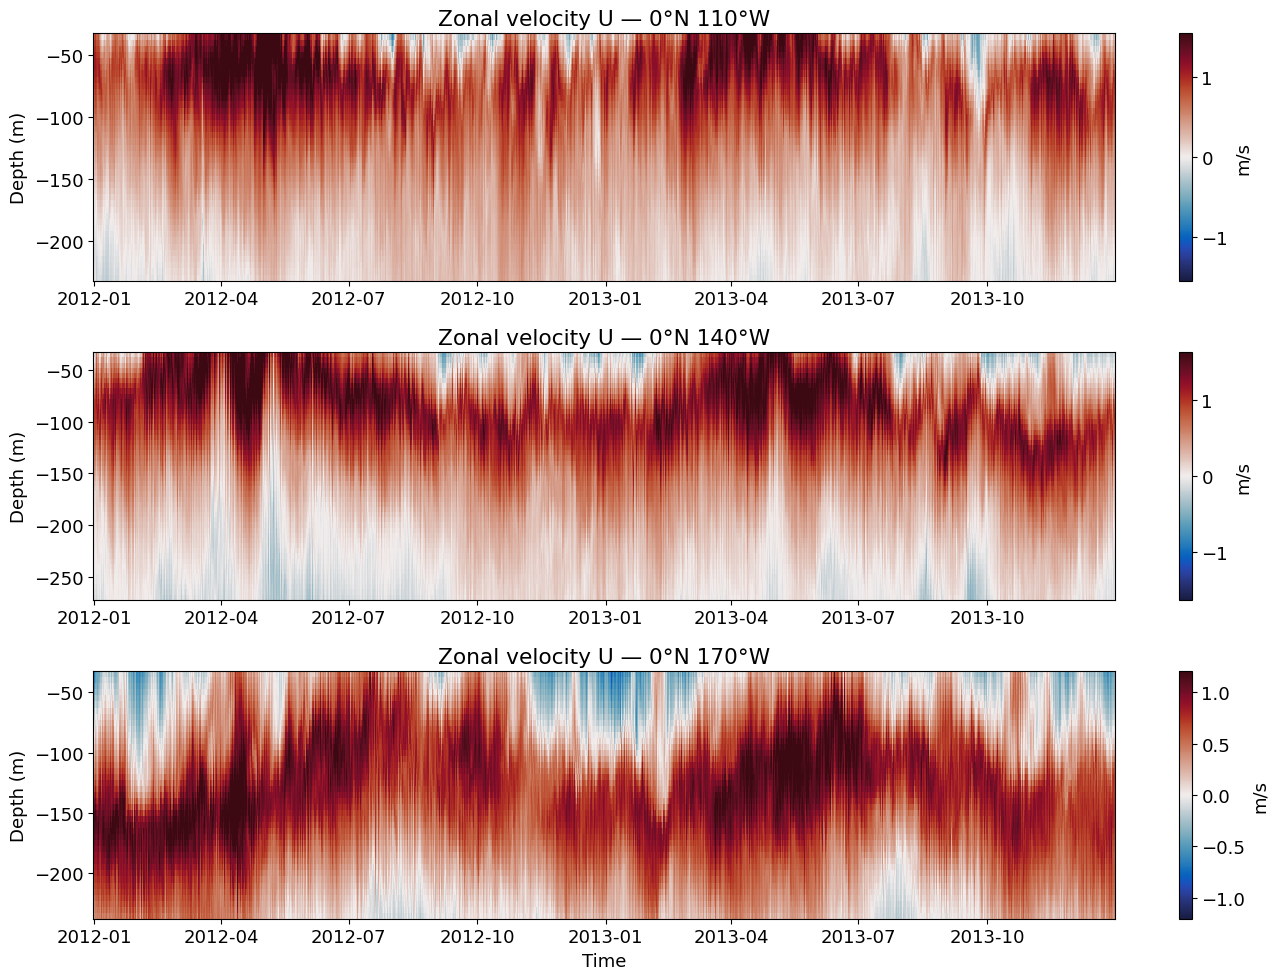

In [4]:
# --- Intermediate plot: 2D time–depth heatmap of U ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharey=False)

for ax, moor, label in zip(axes, MOORINGS, LABELS):
    ui  = mooring_data[moor]['usable_idx']
    dep = mooring_data[moor]['usable_deps']
    U   = mooring_data[moor]['U'][:, ui]
    t   = mooring_data[moor]['time']

    # nan-mask back for display (don't want interpolated values shown in heatmap)
    U_raw = mooring_data[moor]['U'][:, ui].copy()

    vlim = np.nanpercentile(np.abs(U_raw), 98)
    pcm  = ax.pcolormesh(t, -dep, U_raw.T,
                         cmap=cmo.balance, vmin=-vlim, vmax=vlim,
                         shading='auto', rasterized=True)
    ax.set_ylabel('Depth (m)')
    ax.set_title(f'Zonal velocity U — {label}')
    plt.colorbar(pcm, ax=ax, label='m/s')

axes[-1].set_xlabel('Time')
fig.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'tao_adcp_U_timeseries_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# --- Compute Welch PSD at each usable depth ---
# fs = 24 cycles/day (hourly data); period axis will naturally be in days
FS      = 24.0   # cycles per day
NPERSEG = 8760   # 365 days × 24 hr/day = 1 year of samples
NOVERLAP = NPERSEG // 2

psd_results = {}
for moor in MOORINGS:
    ui   = mooring_data[moor]['usable_idx']
    deps = mooring_data[moor]['usable_deps']
    U    = mooring_data[moor]['U']
    V    = mooring_data[moor]['V']

    freqs, _ = welch(U[:, ui[0]], fs=FS, nperseg=NPERSEG,
                     noverlap=NOVERLAP, window='hann')
    n_f = len(freqs)
    n_d = len(ui)

    psd_U = np.zeros((n_d, n_f))
    psd_V = np.zeros((n_d, n_f))

    for i, di in enumerate(ui):
        _, psd_U[i] = welch(U[:, di], fs=FS, nperseg=NPERSEG,
                            noverlap=NOVERLAP, window='hann')
        _, psd_V[i] = welch(V[:, di], fs=FS, nperseg=NPERSEG,
                            noverlap=NOVERLAP, window='hann')

    psd_results[moor] = {
        'freqs': freqs,    # cycles/day
        'psd_U': psd_U,    # (n_depths, n_freqs), (m/s)²/cpd
        'psd_V': psd_V,
        'deps':  deps,
    }
    print(f'{moor}: computed PSD at {n_d} depths, {n_f} freq bins '
          f'(period range {1/freqs[-1]:.2f}–{1/freqs[1]:.0f} days)')

adcp0n110w_hr.cdf: computed PSD at 40 depths, 4381 freq bins (period range 0.08–365 days)
adcp0n140w_hr.cdf: computed PSD at 48 depths, 4381 freq bins (period range 0.08–365 days)
adcp0n170w_hr.cdf: computed PSD at 41 depths, 4381 freq bins (period range 0.08–365 days)


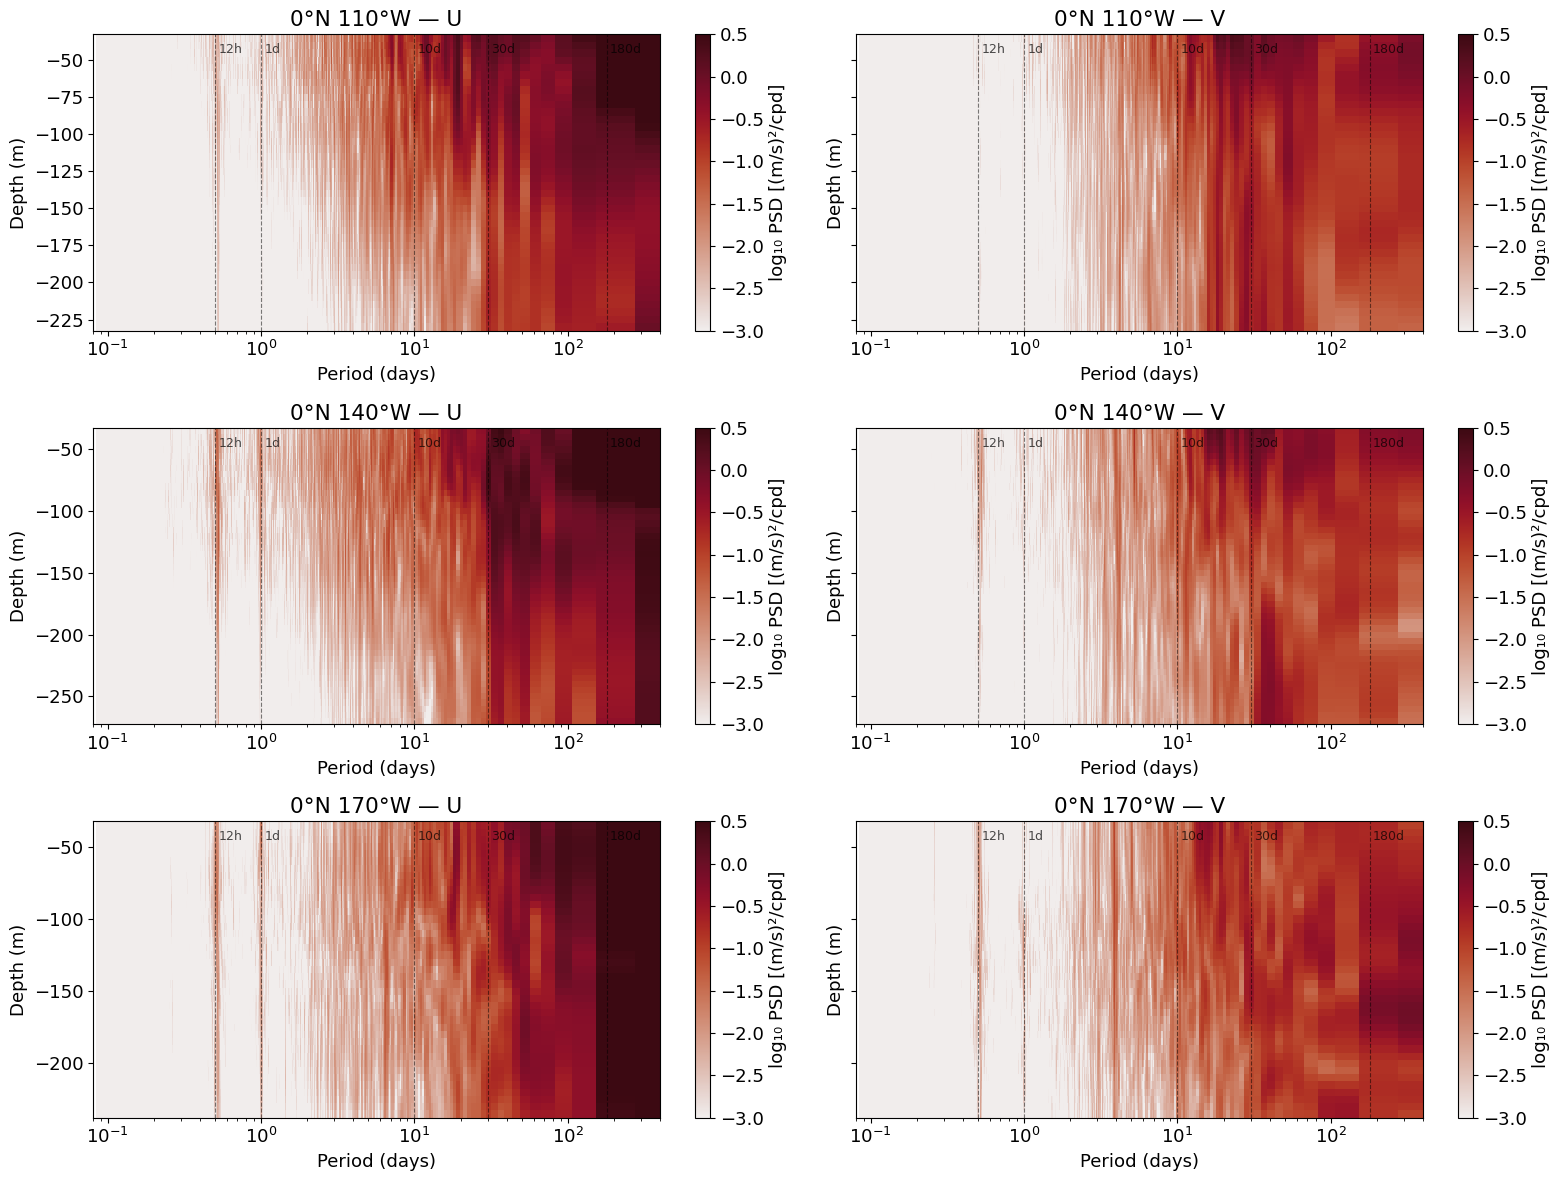

In [13]:
# --- Intermediate plot: 2D depth–period heatmap of PSD ---
# One row per mooring; columns for U and V
# vmin/vmax chosen to highlight TIW band (20–45d, log10 ~ -1 to 0.15 at shallow depths)
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharey='row')

period_lims = (0.08, 400)  # days
VMIN_2D, VMAX_2D = -3.0, 0.5  # log10 PSD scale: clips tidal noise, shows TIW clearly

for row, (moor, label) in enumerate(zip(MOORINGS, LABELS)):
    freqs = psd_results[moor]['freqs']
    deps  = psd_results[moor]['deps']

    # exclude DC (freq=0)
    f_mask  = freqs > 0
    periods = 1.0 / freqs[f_mask]

    for col, var in enumerate(['U', 'V']):
        ax  = axes[row, col]
        psd = psd_results[moor][f'psd_{var}'][:, f_mask]

        pcm = ax.pcolormesh(periods, -deps, np.log10(psd),
                            cmap=cmo.amp, vmin=VMIN_2D, vmax=VMAX_2D,
                            shading='auto', rasterized=True)
        ax.set_xscale('log')
        ax.set_xlim(period_lims)
        ax.set_xlabel('Period (days)')
        ax.set_ylabel('Depth (m)')
        ax.set_title(f'{label} — {var}')
        plt.colorbar(pcm, ax=ax, label='log₁₀ PSD [(m/s)²/cpd]')

        # mark key timescales; use get_xaxis_transform so y is in axes coords
        for p, name in [(0.5, '12h'), (1, '1d'), (10, '10d'), (30, '30d'), (180, '180d')]:
            ax.axvline(p, color='k', lw=0.8, ls='--', alpha=0.5)
            ax.text(p * 1.05, 0.97, name, fontsize=9, va='top', ha='left',
                    color='k', alpha=0.7, transform=ax.get_xaxis_transform())

fig.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'tao_adcp_psd_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# --- Depth-integrate PSD: sum(PSD × DZ) over usable depths ---
# Units: (m/s)²/cpd × m = m³/s²/cpd

for moor in MOORINGS:
    psd_U = psd_results[moor]['psd_U']   # (n_depths, n_freqs)
    psd_V = psd_results[moor]['psd_V']
    psd_KE = psd_U + psd_V               # KE = U² + V² (per unit mass, ×½ omitted — consistent)

    psd_results[moor]['psd_U_int']  = np.sum(psd_U,  axis=0) * DZ
    psd_results[moor]['psd_V_int']  = np.sum(psd_V,  axis=0) * DZ
    psd_results[moor]['psd_KE_int'] = np.sum(psd_KE, axis=0) * DZ

    dep_range = psd_results[moor]['deps']
    print(f'{moor}: depth-integrated over {dep_range[0]:.0f}–{dep_range[-1]:.0f} m '
          f'({len(dep_range)*DZ:.0f} m total column)')

adcp0n110w_hr.cdf: depth-integrated over 35–230 m (200 m total column)
adcp0n140w_hr.cdf: depth-integrated over 35–270 m (240 m total column)
adcp0n170w_hr.cdf: depth-integrated over 35–235 m (205 m total column)


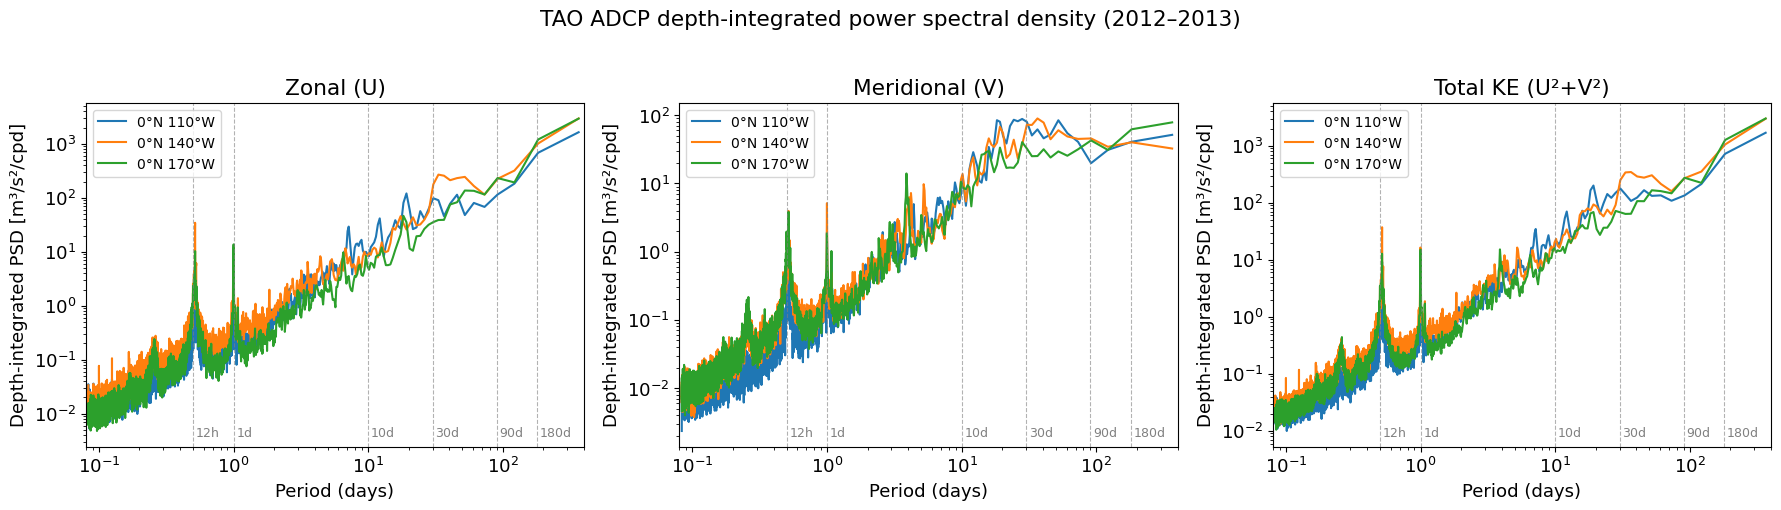

In [8]:
# --- Plot 1: Depth-integrated PSD vs period ---
# 3 subplots (U, V, KE); 3 lines per subplot (one per mooring)

TIMESCALES = [(0.5, '12h'), (1, '1d'), (10, '10d'), (30, '30d'), (90, '90d'), (180, '180d')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, var, title in zip(axes, ['U', 'V', 'KE'],
                          ['Zonal (U)', 'Meridional (V)', 'Total KE (U²+V²)']):
    for moor, label, color in zip(MOORINGS, LABELS, COLORS):
        freqs   = psd_results[moor]['freqs']
        f_mask  = freqs > 0
        periods = 1.0 / freqs[f_mask]
        psd_int = psd_results[moor][f'psd_{var}_int'][f_mask]

        ax.loglog(periods, psd_int, color=color, lw=1.5, label=label)

    # use get_xaxis_transform: x in data coords, y in axes coords (0–1)
    for p, name in TIMESCALES:
        ax.axvline(p, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax.text(p * 1.05, 0.02, name, fontsize=9, va='bottom', ha='left',
                color='gray', transform=ax.get_xaxis_transform())

    ax.set_xlabel('Period (days)')
    ax.set_ylabel('Depth-integrated PSD [m³/s²/cpd]')
    ax.set_title(title)
    ax.set_xlim(0.08, 400)
    ax.legend(fontsize=10)

fig.suptitle('TAO ADCP depth-integrated power spectral density (2012–2013)', y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'tao_adcp_psd_integrated.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# --- Cumulative energy fraction vs period ---
# For each mooring and variable:
# cum_frac(P) = fraction of total energy at periods <= P
# (i.e., cumulative sum from high-frequency end)

for moor in MOORINGS:
    freqs  = psd_results[moor]['freqs']
    f_mask = freqs > 0   # exclude DC
    f      = freqs[f_mask]
    df     = np.diff(f, prepend=f[0] - (f[1]-f[0]))  # uniform spacing from Welch

    for var in ['U', 'V', 'KE']:
        psd_int = psd_results[moor][f'psd_{var}_int'][f_mask]

        energy_per_bin = psd_int * df      # energy in each frequency bin
        total_energy   = energy_per_bin.sum()

        # sort from high freq → low freq (short period → long period)
        # cumsum gives fraction at periods <= current period
        idx_desc       = np.argsort(f)[::-1]
        cum             = np.cumsum(energy_per_bin[idx_desc]) / total_energy
        # reorder to match freq-ascending (period-descending) for plotting
        cum_frac        = np.empty_like(cum)
        cum_frac[idx_desc] = cum

        psd_results[moor][f'cum_frac_{var}'] = cum_frac
        psd_results[moor][f'total_energy_{var}'] = total_energy
        psd_results[moor][f'f_noDC'] = f

print('Cumulative energy fractions computed.')

Cumulative energy fractions computed.


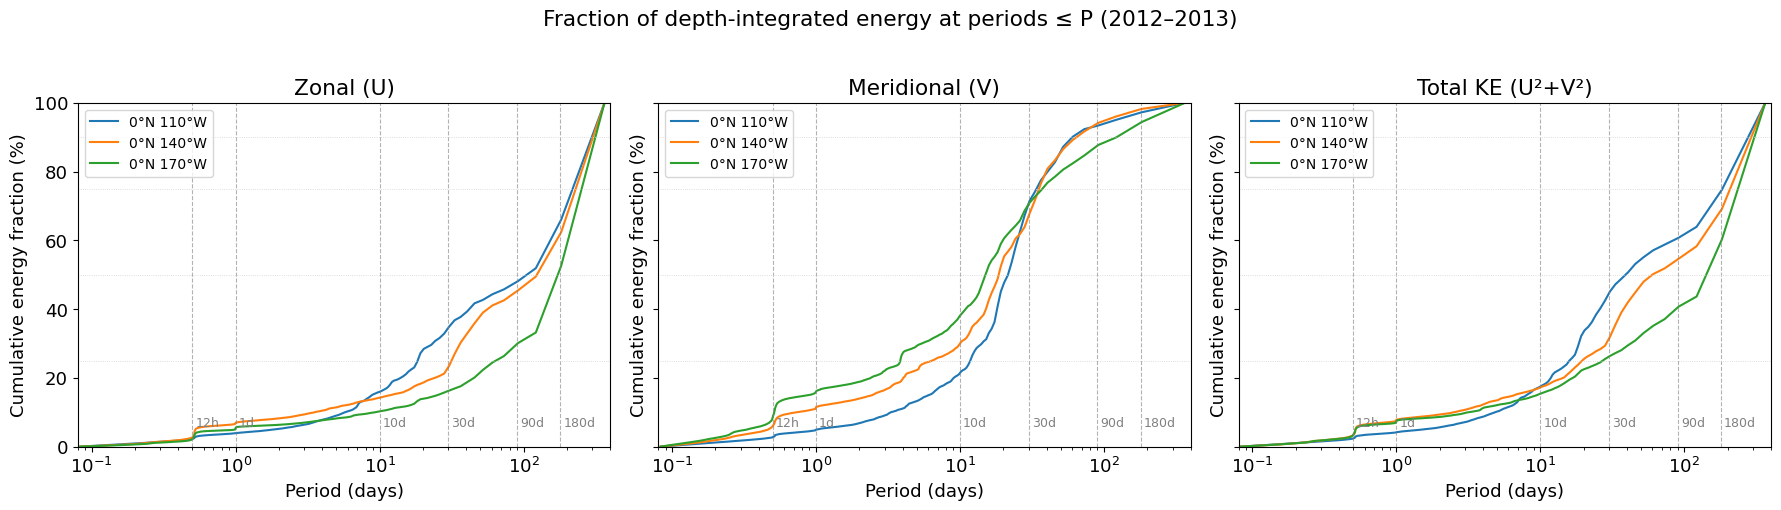

In [10]:
# --- Plot 2: Cumulative energy fraction vs period ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, var, title in zip(axes, ['U', 'V', 'KE'],
                          ['Zonal (U)', 'Meridional (V)', 'Total KE (U²+V²)']):
    for moor, label, color in zip(MOORINGS, LABELS, COLORS):
        f        = psd_results[moor]['f_noDC']
        periods  = 1.0 / f
        cum_frac = psd_results[moor][f'cum_frac_{var}']

        ax.semilogx(periods, cum_frac * 100, color=color, lw=1.5, label=label)

    for p, name in TIMESCALES:
        ax.axvline(p, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax.text(p * 1.05, 5, name, fontsize=9, va='bottom', ha='left', color='gray')

    for pct in [25, 50, 75, 90]:
        ax.axhline(pct, color='lightgray', lw=0.6, ls=':')

    ax.set_xlabel('Period (days)')
    ax.set_ylabel('Cumulative energy fraction (%)')
    ax.set_title(title)
    ax.set_xlim(0.08, 400)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=10)

fig.suptitle('Fraction of depth-integrated energy at periods ≤ P (2012–2013)', y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'tao_adcp_cumulative_energy.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# --- Tidal peak identification ---
# Find spectral peaks at periods <= 1 day and match to known tidal constituents.
# Known constituent periods in hours (from harmonic analysis literature).
TIDAL_CONSTITUENTS = {
    'M2':  12.4206,   # principal lunar semidiurnal
    'S2':  12.0000,   # principal solar semidiurnal
    'N2':  12.6583,   # larger lunar elliptic semidiurnal
    'K2':  11.9672,   # lunisolar semidiurnal
    'L2':  12.1916,   # smaller lunar elliptic semidiurnal
    'ν2':  12.6260,   # larger lunar evectional semidiurnal
    'K1':  23.9345,   # lunisolar diurnal
    'O1':  25.8194,   # principal lunar diurnal
    'P1':  24.0659,   # principal solar diurnal
}
MATCH_TOL_H = 0.15  # hours; ~5× Welch frequency resolution at 12h

rows = []
for moor, label in zip(MOORINGS, LABELS):
    freqs   = psd_results[moor]['freqs']
    f_mask  = (freqs > 0) & (freqs >= 1.0)   # periods <= 1 day
    f_sub   = freqs[f_mask]
    periods_h = (1.0 / f_sub) * 24.0          # convert to hours

    for var in ['U', 'V', 'KE']:
        psd_sub = psd_results[moor][f'psd_{var}_int'][f_mask]
        peaks, props = find_peaks(psd_sub, prominence=psd_sub.max() * 0.05)
        if len(peaks) == 0:
            continue
        for pk in peaks:
            ph = periods_h[pk]
            # find nearest tidal constituent within tolerance
            nearest = min(TIDAL_CONSTITUENTS.items(), key=lambda x: abs(x[1] - ph))
            constituent = nearest[0] if abs(nearest[1] - ph) <= MATCH_TOL_H else '—'
            rows.append({
                'Mooring':       label,
                'Variable':      var,
                'Period (h)':    round(ph, 2),
                'Constituent':   constituent,
                'Prominence':    round(props['prominences'][list(peaks).index(pk)], 4),
            })

df_peaks = (pd.DataFrame(rows)
              .sort_values(['Variable', 'Mooring', 'Period (h)'])
              .reset_index(drop=True))
display(df_peaks)

,Mooring,Variable,Period (h),Constituent,Prominence
0,0°N 110°W,KE,12.00,S2,1.0921
1,0°N 110°W,KE,12.43,M2,9.1562
2,0°N 110°W,KE,12.66,N2,0.5834
3,0°N 110°W,KE,23.93,K1,1.0962
4,0°N 140°W,KE,11.98,K2,1.9980
...,...,...,...,...,...
61,0°N 170°W,V,12.64,ν2,0.3866
62,0°N 170°W,V,12.79,N2,0.5638
63,0°N 170°W,V,12.90,—,0.2362
64,0°N 170°W,V,13.23,—,0.2587


In [12]:
# --- KE energy fraction at periods > 12 h and > 24 h ---
# cum_frac(P) = fraction of total energy at periods <= P
# => fraction at periods > threshold = 1 - cum_frac(threshold)

print(f'Fraction of depth-integrated energy at periods exceeding threshold:')
print()

for THRESHOLD_DAYS, label_thresh in [(0.5, '> 12 h'), (1.0, '> 24 h')]:
    print(f'  {label_thresh}:')
    print(f'  {"Mooring":<14}  {"U":>8}  {"V":>8}  {"KE":>8}')
    print(f'  {"-" * 42}')
    for moor, label in zip(MOORINGS, LABELS):
        f        = psd_results[moor]['f_noDC']
        periods  = 1.0 / f
        sort_idx = np.argsort(periods)
        p_sorted = periods[sort_idx]
        row = []
        for var in ['U', 'V', 'KE']:
            cf_sorted = psd_results[moor][f'cum_frac_{var}'][sort_idx]
            frac_above = 1.0 - float(np.interp(THRESHOLD_DAYS, p_sorted, cf_sorted))
            row.append(frac_above)
        print(f'  {label:<14}  {row[0]:>7.1%}  {row[1]:>7.1%}  {row[2]:>7.1%}')
    print()

Fraction of depth-integrated energy at periods exceeding threshold:

  > 12 h:
  Mooring                U         V        KE
  ------------------------------------------
  0°N 110°W         97.8%    97.3%    97.6%
  0°N 140°W         97.3%    94.0%    96.7%
  0°N 170°W         97.8%    91.4%    96.6%

  > 24 h:
  Mooring                U         V        KE
  ------------------------------------------
  0°N 110°W         96.1%    95.1%    95.8%
  0°N 140°W         93.0%    88.5%    92.2%
  0°N 170°W         94.5%    83.9%    92.6%

